# 稿件主图（Figure 2–5）

本 notebook **只做拼图**：数据加载与面板绘制都来自核心包
`src.workflow.figures`（带测试）；这里用 `add_gridspec` 把面板拼成复合主图，
手工标注面板字母，主图存 `dpi=300` PNG + `.pdf` 矢量孪生。图上文字统一英文。

- **Fig 2** 模拟基准：被压制的农业传播（农业人口占比长期低位）
- **Fig 3** 农民→狩猎采集者转换的影响：a 关闭转换；b 不同转换值终态
- **Fig 4** 不同因素下农业扩张效率：a `lam_farmer`；b `lim_h`；c 地貌
- **Fig 5** 水田 vs 旱地农民的差异化影响：a 轨迹；b 终态农业总人口

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "reports":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.workflow import figures as F  # noqa: E402

try:
    from matplotkit import config_font

    config_font("SunTimes")
except Exception as exc:  # 字体缺失不致命，退回默认
    print(f"config_font skipped: {exc}")

sns.set_theme(style="whitegrid", context="notebook")

OUT = PROJECT_ROOT / "reports"
DATA = PROJECT_ROOT / "out/south_china_evolution"

# 全部指向 rerun_v2：run_slurm_rerun.sh 在修好 #28（每步只损失一次）和 #29
# （水稻移民按品种取可耕地掩膜）之后重跑的结果，且首次带随机种子，可逐 run 复现。
# 旧的日期目录仍留在 out/ 下，需要做修复前后对比时再取。
RERUN = DATA / "rerun_v2"

BASELINE_DIR = RERUN / (
    "convert3/22_Farmer.convert_prob.to_hunter=0.1,"
    "Hunter.convert_prob.to_farmer=0.05,Hunter.convert_prob.to_rice=0.05"
)
OFF_DIR = RERUN / (
    "convert3/0_Farmer.convert_prob.to_hunter=0.0,"
    "Hunter.convert_prob.to_farmer=0.0,Hunter.convert_prob.to_rice=0.0"
)
LAM_ROOT = RERUN / "lam"
LIMH_ROOT = RERUN / "limh"
TERRAIN_ROOT = RERUN / "terrain"
# convert_prob 精细网格（Fig 3）：广覆盖 f2h→0.10 悬崖 + 11×11 详查区
BROAD_GRID = RERUN / "grid_broad"  # 6×6，f2h/h2f ∈ [0, 0.10]
FINE_GRID = RERUN / "grid_fine"  # 11×11，f2h ∈ [0, 0.02] × h2f ∈ [0, 0.15]

for _name, _p in [
    ("BASELINE_DIR", BASELINE_DIR),
    ("OFF_DIR", OFF_DIR),
    ("LAM_ROOT", LAM_ROOT),
    ("LIMH_ROOT", LIMH_ROOT),
    ("TERRAIN_ROOT", TERRAIN_ROOT),
    ("BROAD_GRID", BROAD_GRID),
    ("FINE_GRID", FINE_GRID),
]:
    if not _p.exists():
        raise FileNotFoundError(
            f"{_name} 不存在: {_p}\n"
            "先把重跑结果同步下来：make fetch-rerun\n"
            "再核对完整性：bash run_slurm_rerun.sh --verify"
        )


def save_fig(fig, name: str, dpi: int = 300) -> None:
    """主图存 PNG + 同名 .pdf 矢量孪生。"""
    png = OUT / f"{name}.png"
    fig.savefig(png, dpi=dpi, bbox_inches="tight")
    fig.savefig(png.with_suffix(".pdf"), bbox_inches="tight")
    print(f"saved: {png}  (+ .pdf)")

## Figure 2 — 模拟基准：被压制的农业传播

**这张图讲什么**：用模型默认参数(baseline)跑出来的一条曲线，纵轴是「农业人口占
总人口的比例」$s_t = (N^F + N^R)/(N^F + N^R + N^H)$，横轴是时间步。5 次重复取均值
±95% CI。

**怎么读**：曲线从 0 起步、缓慢爬升，到 500 步终态也只有约 17–18%（图上虚线标出
终态水平）。也就是说，在整个模拟周期里，农业人口始终是「少数派」，绝大多数人口
仍是狩猎采集者。

**结论**：为什么压不上去？因为狩猎采集者常年顶在全局承载力上限 $K_H = k_H\,A$
附近（每个非水体栅格 35 人），把空间与人口占满，农业只能在夹缝里缓慢渗透。这就
复现了考古观察到的「农业进入华南后长期受压制」的现象，为后面逐一拆解压制机制
提供了参照基准。

saved: /Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/reports/figure2_baseline_suppression.png  (+ .pdf)


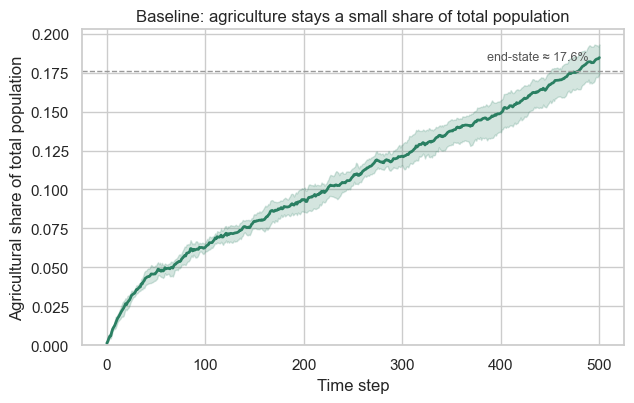

In [2]:
baseline = F.load_single_run(BASELINE_DIR, "baseline")

fig = plt.figure(figsize=(6.5, 4.2))
ax = fig.add_subplot(111)
F.plot_agri_share(baseline, ax=ax)
ax.set_title("Baseline: agriculture stays a small share of total population")

# 终态占比标注（末 50 步均值）
_end = F._agri_share(baseline[baseline["step"] >= baseline["step"].max() - 50]).mean()
ax.axhline(_end, ls="--", lw=1, color="#999999")
ax.annotate(
    f"end-state ≈ {_end:.1%}",
    xy=(baseline["step"].max(), _end),
    xytext=(-8, 8),
    textcoords="offset points",
    ha="right",
    fontsize=9,
    color="#555555",
)
fig.tight_layout()
save_fig(fig, "figure2_baseline_suppression")
plt.show()

## Figure 3 — 农民→狩猎采集者转换的影响

**这张图讲什么**：本图论证「农民↔狩猎采集者之间的转化，尤其是 `f2h`
（farmer→hunter，小农群退化回狩猎采集）这条路径，是压制农业的主导机制」。同一个
结论用三个由粗到细的层次呈现，逐级夯实。

**a — 二值对照（开 vs 关）**：灰线是 baseline（转化开启），红线是把 3 条
hunter↔farmer/rice 转化路径全部关掉。关掉之后普通农民规模一路飙到 ~30 万，而
baseline 常年压在 ~1.5 万——**转化机制一关，农业立刻「解禁」**，说明它确实是刹车。

**b — f2h「悬崖」曲线**：横轴把 `f2h` 细分到 0.02 间隔（0→0.10），每条线是一个
`h2f` 切片，纵轴 log。可以看到 `f2h` 从 0 迈到约 0.02 这**一小步**就吃掉了绝大部分
跌幅（金色阴影标出的详查区），之后是缓慢的渐近衰减。这解释了「为什么要放大
[0, 0.02] 段」——真正的质变发生在这里。

**c — 11×11 精细响应面**：在详查区 `f2h∈[0,0.02] × h2f∈[0,0.15]` 上做 11×11
全网格热图。**纵向（f2h）梯度极强、横向（h2f）梯度很弱**：底部 f2h≈0 一整行亮黄
（农民多），往上迅速变暗。这直观说明 `f2h` 主导、`h2f` 次之。log 空间的可分离
可加模型 $\log N \approx \alpha(f2h)+\beta(h2f)+\gamma$ 拟合优度 $R^2 = 0.992$，
仅在高-高角落有微弱正交互——即两条路径近似「各管一轴、可加」。

saved: /Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/reports/figure3_conversion.png  (+ .pdf)


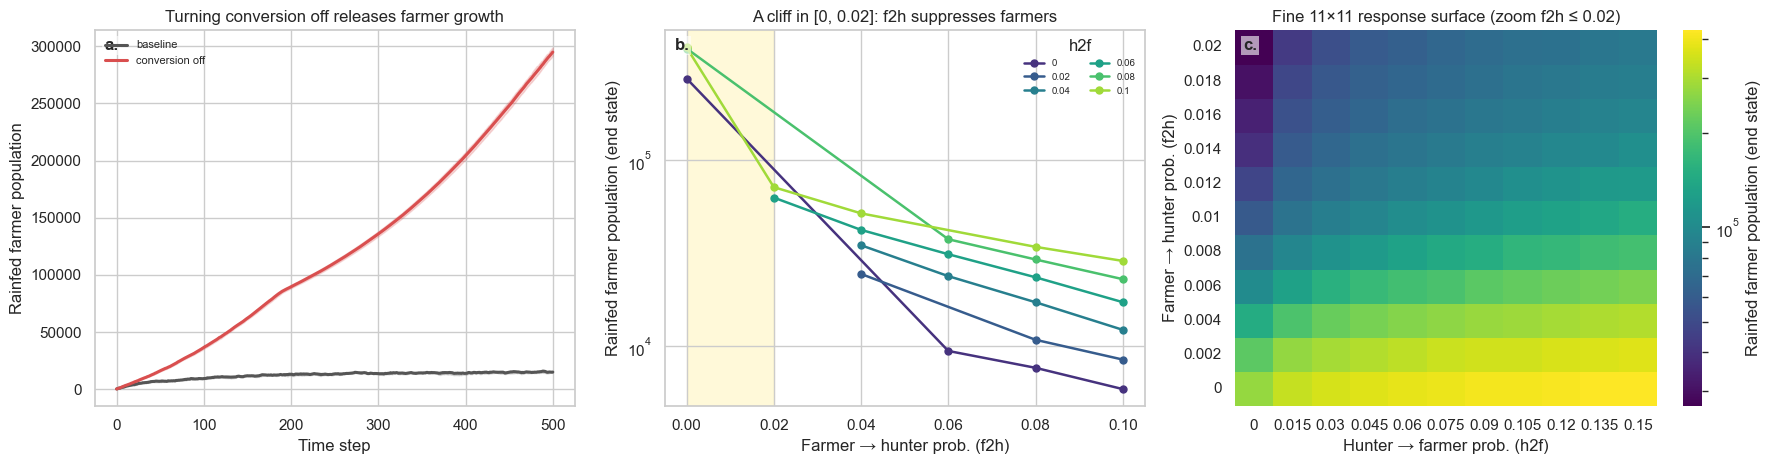

In [3]:
base_run = F.load_single_run(BASELINE_DIR, "baseline")
off_run = F.load_single_run(OFF_DIR, "conversion off")
off_vs_on = pd.concat([base_run, off_run], ignore_index=True)

broad = F.load_fine_grid(BROAD_GRID)  # 6×6 广覆盖：f2h 悬崖曲线
fine = F.load_fine_grid(FINE_GRID)  # 11×11 详查区：响应面

fig = plt.figure(figsize=(18, 4.8))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.1])

ax_a = fig.add_subplot(gs[0, 0])
F.plot_convert_off_vs_on(off_vs_on, ax=ax_a)
ax_a.set_title("Turning conversion off releases farmer growth")
F.panel_label(ax_a, "a")

ax_b = fig.add_subplot(gs[0, 1])
F.plot_f2h_cliff(broad, ax=ax_b, shade=(0.0, 0.02))
ax_b.set_title("A cliff in [0, 0.02]: f2h suppresses farmers")
F.panel_label(ax_b, "b")

ax_c = fig.add_subplot(gs[0, 2])
F.plot_grid_heatmap(fine, ax=ax_c, log=True)
ax_c.set_title("Fine 11×11 response surface (zoom f2h ≤ 0.02)")
F.panel_label(ax_c, "c")

fig.tight_layout()
save_fig(fig, "figure3_conversion")
plt.show()

## Figure 4 — 不同因素下农业扩张效率对比

**这张图讲什么**：把「除转化以外的三个候选因素」放在同一把尺子上比较它们对农业
扩张的影响大小。三个面板纵轴统一为普通农民人口 `num_farmers_n`（农业扩张效率的
代表指标），横轴都是时间步，5 次重复取均值 ±95% CI。这样面板之间「曲线拉开的
幅度」就能直接横向对比。

**a — `lam_farmer`（旱地农民涌入速率 $\lambda_F$）**：由 2 增到 10，农民终态水平
随之抬升，曲线拉开明显——涌入速率是有效的调节量。

**b — `lim_h`（狩猎采集者人口上限 $k_H$）**：取 15/25/35（35 为基准）。上限越低
理论上给农业让出越多空间，但三条线只是温和分离，**远不如转化的量级**。

**c — 地貌（真实 vs 均质化）**：把真实 DEM/坡度替换成均质面（只均质坡度 / 只均质
DEM / 完全均质化）。即便把地形彻底抹平，农民终态也只抬升到同数量级（约 1.8×），
曲线形态没有质变。

**结论**：`lim_h` 与地貌都只有「次级」贡献，效应比 Figure 3 里 `f2h` 的量级小得多。
换句话说，压制农业的关键不在环境本身，而在人群间的转化机制。（注：草图上把
Hunter/Rice 面板划掉，这里只保留农业面板，聚焦「农业扩张效率」这一条线。）

saved: /Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/reports/figure4_expansion_factors.png  (+ .pdf)


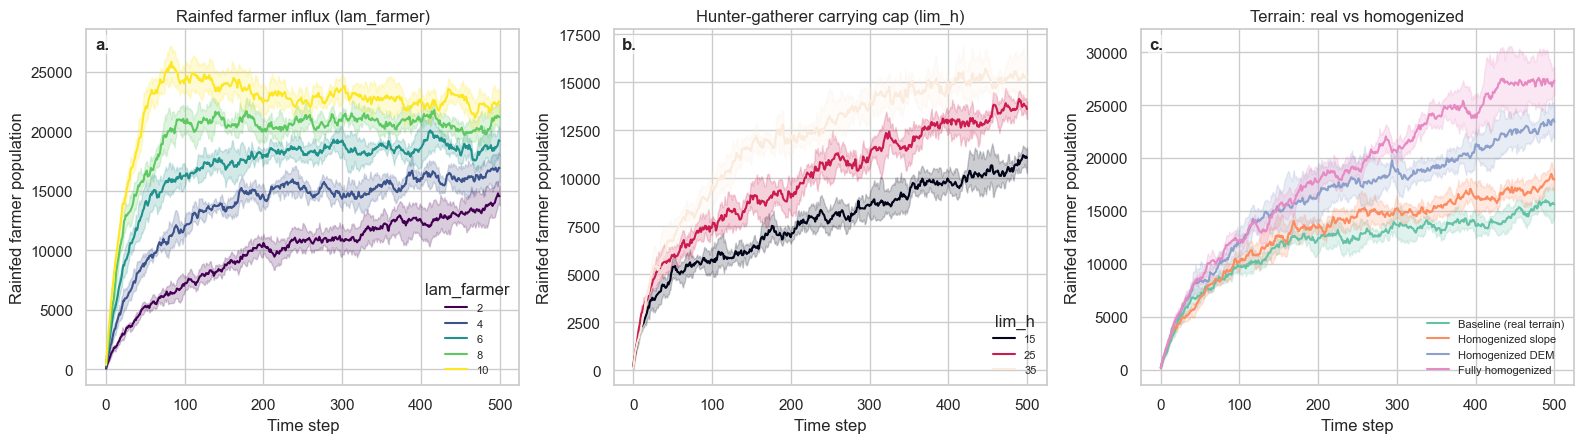

In [4]:
lam = F.load_trajectories(LAM_ROOT)
lam_slice = lam[np.isclose(lam["env.lam_ricefarmer"], 0.1)].copy()
lam_slice["env.lam_farmer"] = lam_slice["env.lam_farmer"].astype(int)

limh = F.load_trajectories(LIMH_ROOT)
limh["env.lim_h"] = limh["env.lim_h"].astype(int)

terrain = F.load_terrain(TERRAIN_ROOT)
terrain_order = list(F.TERRAIN_LABELS.values())

fig = plt.figure(figsize=(16, 4.6))
gs = fig.add_gridspec(1, 3)

ax_a = fig.add_subplot(gs[0, 0])
F.plot_metric_by_hue(
    lam_slice, hue="env.lam_farmer", ax=ax_a, ylabel="Rainfed farmer population"
)
ax_a.set_title("Rainfed farmer influx (lam_farmer)")
ax_a.get_legend().set_title("lam_farmer")
F.panel_label(ax_a, "a")

ax_b = fig.add_subplot(gs[0, 1])
F.plot_metric_by_hue(
    limh, hue="env.lim_h", ax=ax_b, palette="rocket", ylabel="Rainfed farmer population"
)
ax_b.set_title("Hunter-gatherer carrying cap (lim_h)")
ax_b.get_legend().set_title("lim_h")
F.panel_label(ax_b, "b")

ax_c = fig.add_subplot(gs[0, 2])
F.plot_metric_by_hue(
    terrain,
    hue="scenario",
    ax=ax_c,
    palette="Set2",
    hue_order=terrain_order,
    ylabel="Rainfed farmer population",
)
ax_c.set_title("Terrain: real vs homogenized")
ax_c.get_legend().set_title("")
F.panel_label(ax_c, "c")

fig.tight_layout()
save_fig(fig, "figure4_expansion_factors")
plt.show()

## Figure 5 — 水田 vs 旱地农民涌入的差异化影响

**这张图讲什么**：比较两股农业移民流——旱地农民 $\lambda_F$ 与水田农民
$\lambda_R$——对「农业总人口」$N^F + N^R$ 的撬动力谁更强。做法是把
`lam_farmer × lam_ricefarmer` 网格切成两片（各只变一个参数），再把每个参数归一化成
「相对基准的倍数」，这样两个量纲不同的参数能放在同一横轴上比。

**a — 轨迹**：左右两个子面板分别是 `lam_farmer` 扫描、`lam_ricefarmer` 扫描，颜色
由深到浅 = 1×→5× 基准。可以看到右图（水田扫描）在高倍数下把农业总人口拉得更高、
更陡。

**b — 终态响应**：横轴是参数倍数、纵轴是终态农业总人口，两条线对比斜率。
**`lam_ricefarmer`（橙）的斜率明显陡于 `lam_farmer`（蓝）**——同样是相对基准翻几倍，
增加水田农民涌入带来的农业人口增量远大于增加旱地农民。

**结论**：水田农民虽然涌入频率低（基准 $\lambda_R = 0.1$，远小于 $\lambda_F = 3$），
但「以一当十」——单位涌入对农业扩散的撬动作用显著强于旱地农民。机制上，水田农民
单群规模大（200–300 人）、增长率略高，一旦落地就能形成更大的农业据点。

saved: /Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/reports/figure5_paddy_vs_dryland.png  (+ .pdf)


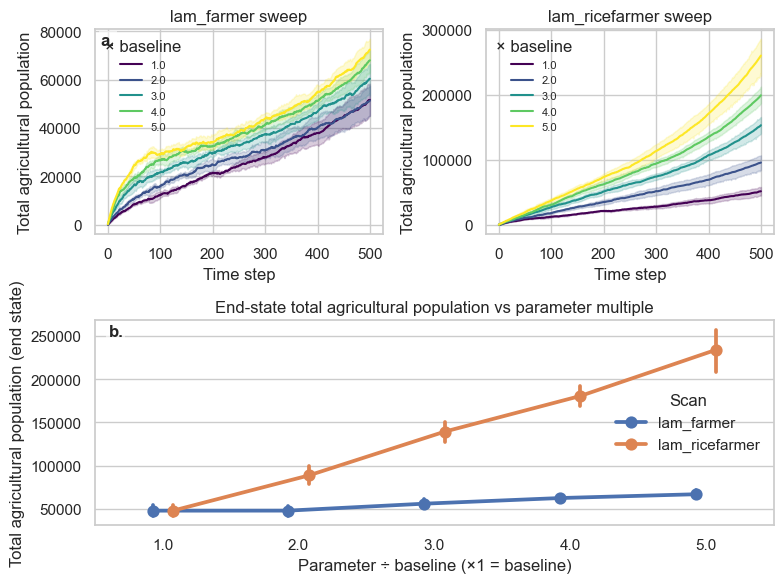

In [5]:
lev = F.build_leverage_frame(F.load_trajectories(LAM_ROOT))

fig = plt.figure(figsize=(8, 6))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# a: 两条 scan 的轨迹（各一子面板）
for j, scan in enumerate(["lam_farmer", "lam_ricefarmer"]):
    ax = fig.add_subplot(gs[0, j])
    F.plot_metric_by_hue(
        lev[lev["scan"] == scan],
        hue="param_mult",
        ax=ax,
        metric="agri_n",
        ylabel="Total agricultural population",
    )
    ax.set_title(f"{scan} sweep")
    ax.get_legend().set_title("× baseline")
    if j == 0:
        F.panel_label(ax, "a")

# b: 终态响应对比（跨底部）
ax_b = fig.add_subplot(gs[1, :])
F.plot_leverage_endstate(lev, ax=ax_b)
ax_b.set_title("End-state total agricultural population vs parameter multiple")
F.panel_label(ax_b, "b")

fig.tight_layout()
save_fig(fig, "figure5_paddy_vs_dryland")
plt.show()